# Model training and testing

In the following notebook we will work with the numpy data generated by the 1.0-jrb-data-preprocessing.ipynb notebook to train and test machine learning models.

### First model: ANN in keras, undersampling the majority class for balance

We must start by loading the data generated by the pre-processing notebook. This includes the CSV detailing the training, test and validation sets, and the already generated numpy matrices from this sets. Using the fact that the numpy matrices are ordered just like the csv files (the first row of each csv file has it's data encoded in the first row of the corresponding numpy label and spectrum matrices, and so on), we will decode the one hot encoding dictionary used to generate the label matrix, using the vsz.ohe_decoder funtion.

In [6]:
# now we will load the training and validation set matrices

import numpy as np
from pathlib import Path
import os

# Define the base project dir and the current dir, for relative path use.

project_dir =  Path(globals()['_dh'][0]).parent
current_dir =  Path(globals()['_dh'][0])   

train_label_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\training_label_matrix.npy'))
valid_label_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\validation_label_matrix.npy'))
train_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\training_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\1.0-jrb-alternative-approach\validation_spectrum_matrix.npy'))

In [46]:
# Let's make a folder to store our results.

try:
    os.mkdir(os.path.join(current_dir, '1.0-jrb-first_model_test'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

In [7]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.visualization.visualize as vsz
import pandas as pd

train_csv_path = os.path.join(project_dir, r'data\processed\train_set.csv')
train_set = pd.read_csv (train_csv_path)
stars_encoding = vsz.ohe_decoder(train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(stars_encoding)

In [8]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape, valid_label_matrix.shape)

(3366, 4200) (3366, 12) (1123, 4200) (1123, 12)


Now, we are still facing the problem of having to train an umbalanced set. There are many strategies which will have to be explored in order to solve this issue. For example:

<ul>
  <li>We could undersample the biggest dataset, oversample it, or a combination of both. There are also numerous algorithms to do so.</li>
  <li>We could take advantage of the fact that there are a number of different observations from the same object so as to perform data augmentation using those spectrums, instead of one per object.</li>
  <li>We could use class weights in the optimization process, as a parameter to the model.fit call.</li>
  <li>We could perform other data augmentation techniques, like looking for other similarly classified spectra elsewhere, building synthetic spectra, etc.</li>
</ul> 

First, we'll simply undersample the majority class in the trainig set. Code is also available (commented) to try out the class wegiht parameter for model.fit

## ANN: undersampling the majority class.

In [9]:
# Resampling the majority dataset in order to balance the set.

from imblearn.under_sampling import RandomUnderSampler
under_sampler = RandomUnderSampler(random_state=40, sampling_strategy='majority')
X_under, Y_under = under_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

We can now see the distribution of the one hot encoded labels

In [10]:
from collections import Counter

newLabels = Counter()
for label in Y_under:
    for idx, key in enumerate(label):
         newLabels[idx]+=key

print(newLabels)

Counter({4: 327, 9: 215, 2: 201, 8: 135, 5: 80, 6: 70, 10: 67, 1: 55, 7: 31, 3: 10, 0: 6, 11: 6})


Now we can take our resample data (which resampled or in this case, undersampled the majority class) and train our ANN model. This particular ANN structure will have the same hidden layers and acxtivation functions found in Sharma et al, but other parameters may not be the same.

In [82]:
# Code to inpuit class weights parameter for model.fit

# First we'll define a class weight dictionary
# from sklearn.utils.class_weight import compute_class_weight

# y_integers = np.argmax(train_label_matrix, axis=1)
# class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
# d_class_weights = dict(enumerate(class_weights))
# print(d_class_weights)

We now proceed to define our model, and other relevant parameters for training the ANN using keras. We will train our model using a batch size of 32 samples (our ANN weights will be updated using batches or chunks of 32 samples) and for 30 epochs (we will go over our training set for a total of 30 times doing optmization).

In [25]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD

In [26]:
#opt = SGD(lr=0.001)

model = Sequential([Dense(4200, input_dim = 4200, activation='relu', kernel_initializer='uniform'),
                    Dense(128, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.4),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.4),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(stars_encoding), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_under,Y_under, batch_size=32, epochs=30 , validation_data=(valid_spectrum_matrix, valid_label_matrix))

Epoch 1/30
38/38 [==============================] - 2s 49ms/step - loss: 2.1320 - accuracy: 0.3516 - val_loss: 3.3954 - val_accuracy: 0.1630
Epoch 2/30
38/38 [==============================] - 2s 46ms/step - loss: 2.4478 - accuracy: 0.4264 - val_loss: 4.4510 - val_accuracy: 0.1719
Epoch 3/30
38/38 [==============================] - 2s 47ms/step - loss: 2.3564 - accuracy: 0.4522 - val_loss: 3.9433 - val_accuracy: 0.1861
Epoch 4/30
38/38 [==============================] - 2s 47ms/step - loss: 1.7735 - accuracy: 0.4755 - val_loss: 4.2862 - val_accuracy: 0.1763
Epoch 5/30
38/38 [==============================] - 2s 46ms/step - loss: 1.7468 - accuracy: 0.4921 - val_loss: 3.7281 - val_accuracy: 0.1825
Epoch 6/30
38/38 [==============================] - 2s 46ms/step - loss: 1.7335 - accuracy: 0.4946 - val_loss: 3.4673 - val_accuracy: 0.2021
Epoch 7/30
38/38 [==============================] - 2s 46ms/step - loss: 1.6957 - accuracy: 0.5162 - val_loss: 3.5999 - val_accuracy: 0.2012
Epoch 8/30
38

Now that we have trained the model, we can see it's metrics

In [27]:
from sklearn.metrics import confusion_matrix

valid_sample_output = model.predict(valid_spectrum_matrix, batch_size=60)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

19/19 [==============================] - 0s 9ms/step


In [28]:
stars_encoding

{'WDA': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDB': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WD+MS': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WD': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]),
 'CV': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}

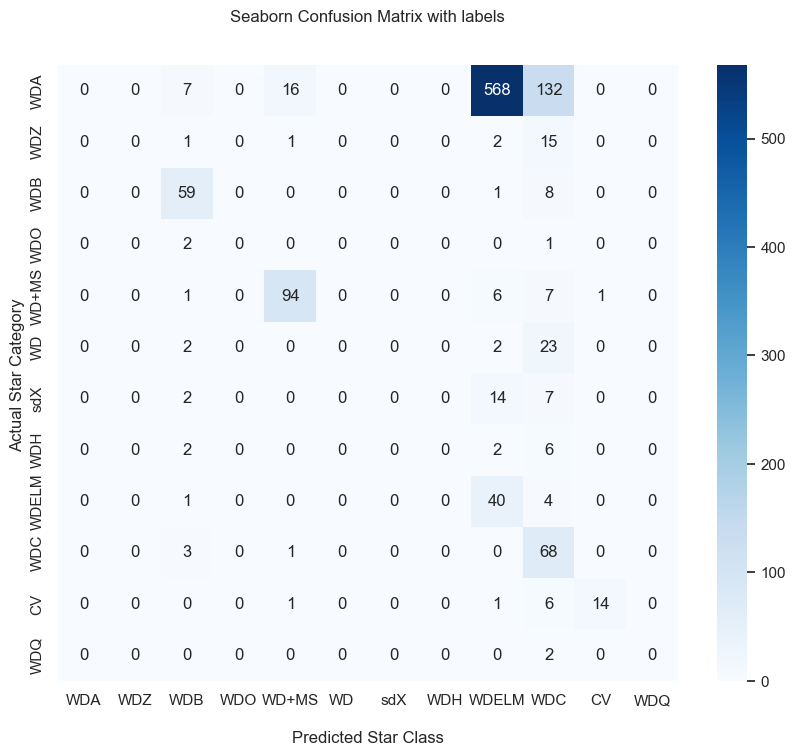

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc = {'figure.figsize':(10,8)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

This confussion matrix shows that, using our undersampling scheme, the most problematic class turns out to be the WDA class! This may mean, for example, that we should explore a more inteligent undersampling algorithm (intead of random undersampling) so as to preserve the most information possible. Of course, we could also explore any other data augmentation scheme, as well as other models.

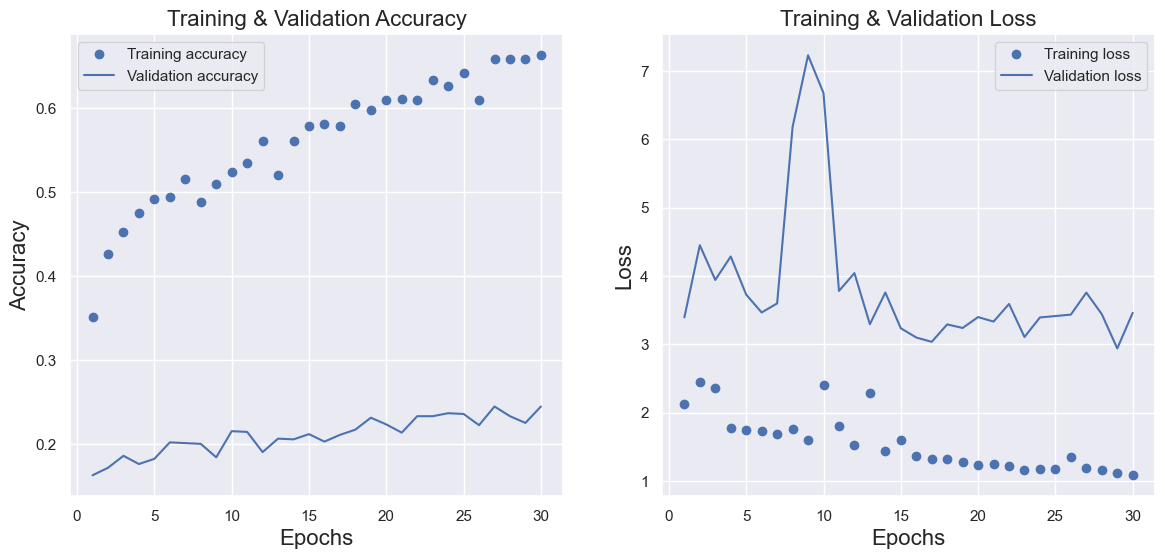

In [30]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

Now, we can see the model is adjusting steadily to the training set, but the validation set does not show good results. Let's try another approach


## Keras ANN: Oversampling the dataset

Now we will try oversampling the dataset. The strategy here is to oversample the minority classes.

In [34]:
# you can run pip install imblearn to get the imbalanced learn module.
# Resampling the majority dataset in order to balance the set.

from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

we now proceed to train an ANN with the same parameter as with the undersampled dataset.

In [35]:
model = Sequential([Dense(4200, input_dim = 4200, activation='relu', kernel_initializer='uniform'),
                    Dense(128, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.4),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.4),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(stars_encoding), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=32, epochs=30 , validation_data=(valid_spectrum_matrix, valid_label_matrix))

Epoch 1/30
814/814 [==============================] - 32s 39ms/step - loss: 2.3187 - accuracy: 0.2152 - val_loss: 2.2218 - val_accuracy: 0.1300
Epoch 2/30
814/814 [==============================] - 32s 39ms/step - loss: 1.7091 - accuracy: 0.4008 - val_loss: 1.2379 - val_accuracy: 0.6527
Epoch 3/30
814/814 [==============================] - 34s 42ms/step - loss: 1.3403 - accuracy: 0.5149 - val_loss: 1.7848 - val_accuracy: 0.6661
Epoch 4/30
814/814 [==============================] - 35s 43ms/step - loss: 1.5793 - accuracy: 0.5822 - val_loss: 0.8257 - val_accuracy: 0.7614
Epoch 5/30
814/814 [==============================] - 33s 41ms/step - loss: 1.1287 - accuracy: 0.6153 - val_loss: 1.1681 - val_accuracy: 0.6723
Epoch 6/30
814/814 [==============================] - 33s 41ms/step - loss: 1.4725 - accuracy: 0.6337 - val_loss: 1.0507 - val_accuracy: 0.7044
Epoch 7/30
814/814 [==============================] - 33s 41ms/step - loss: 2.7733 - accuracy: 0.6374 - val_loss: 0.8254 - val_accuracy:

In [40]:
from sklearn.metrics import confusion_matrix

valid_sample_output = model.predict(valid_spectrum_matrix, batch_size=60)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class, normalize='true')

19/19 [==============================] - 0s 9ms/step


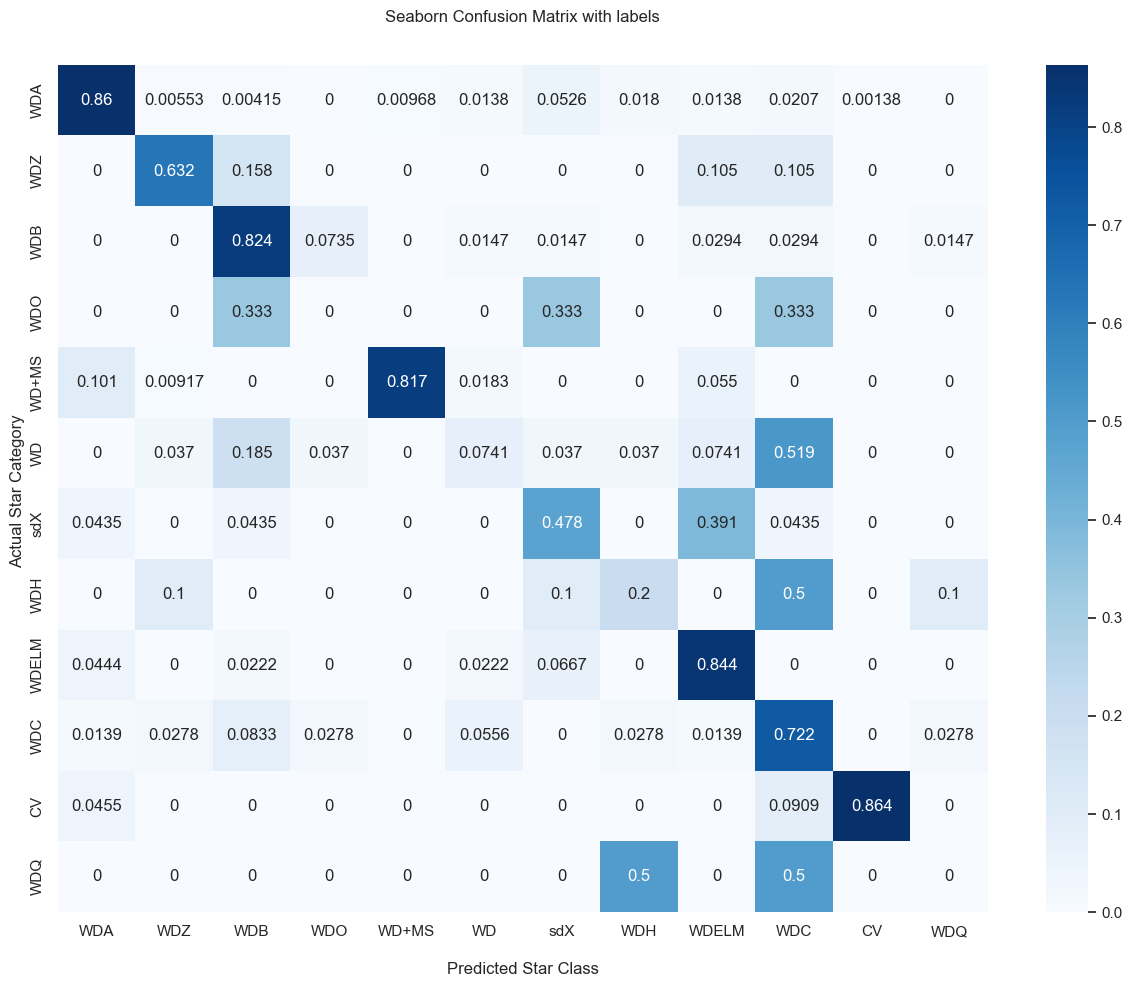

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

star_class = vsz.sort_ohe(stars_encoding)

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

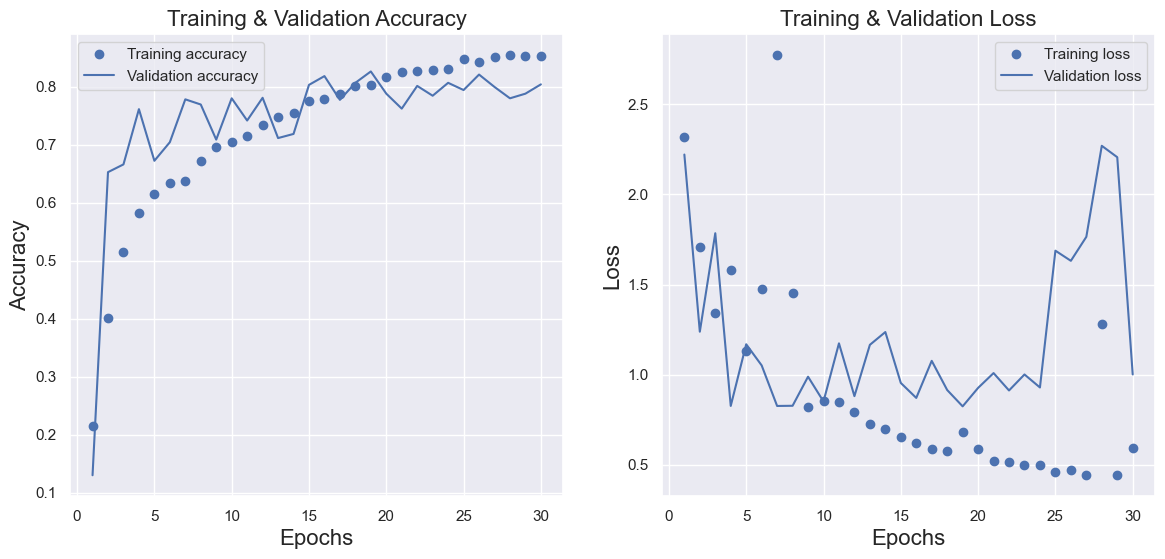

In [42]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

This model actually seems to do quite good! altough we have not validated it sufficiently yet. The validation loss also has strange oscilations.

## 1DCNN using keras! 

We will implement a 1 dimensional convolutional neural network using keras. This type of model is great at detecting basic patterns in 1d data, and gradually integrate it into more abstract concepts. We will also use a callback to save the best model found during training, and by best we mean the one with the lower validation loss.

In [47]:
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [49]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
mc = ModelCheckpoint( os.path.join(current_dir,'1.0-jrb-first_model_test\\cnn_model.h5'), monitor='val_loss', mode='min', verbose=1, save_best_only=True)

model = Sequential([Conv1D(filters=128, kernel_size=4, activation='relu', strides=2, input_shape=(X_over.shape[1],1)),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=64, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=32, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=16, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Flatten(),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(stars_encoding), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=32, epochs=30 , validation_data=(valid_spectrum_matrix, valid_label_matrix), callbacks=[es, mc])

Epoch 1/30
813/814 [============================>.] - ETA: 0s - loss: 1.5008 - accuracy: 0.4809
Epoch 1: val_loss improved from inf to 1.31179, saving model to c:\Users\jotab\Documents\Github\sdss_repo\notebooks\1.0-jrb-first_model_test\cnn_model.h5
814/814 [==============================] - 57s 69ms/step - loss: 1.5003 - accuracy: 0.4810 - val_loss: 1.3118 - val_accuracy: 0.7373
Epoch 2/30
813/814 [============================>.] - ETA: 0s - loss: 0.7707 - accuracy: 0.7388
Epoch 2: val_loss improved from 1.31179 to 0.94888, saving model to c:\Users\jotab\Documents\Github\sdss_repo\notebooks\1.0-jrb-first_model_test\cnn_model.h5
814/814 [==============================] - 56s 69ms/step - loss: 0.7705 - accuracy: 0.7389 - val_loss: 0.9489 - val_accuracy: 0.7542
Epoch 3/30
813/814 [============================>.] - ETA: 0s - loss: 0.5280 - accuracy: 0.8233
Epoch 3: val_loss improved from 0.94888 to 0.94520, saving model to c:\Users\jotab\Documents\Github\sdss_repo\notebooks\1.0-jrb-first_

In [52]:
from sklearn.metrics import confusion_matrix

valid_sample_output = model.predict(valid_spectrum_matrix, batch_size=60)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class, normalize='true')

19/19 [==============================] - 1s 38ms/step


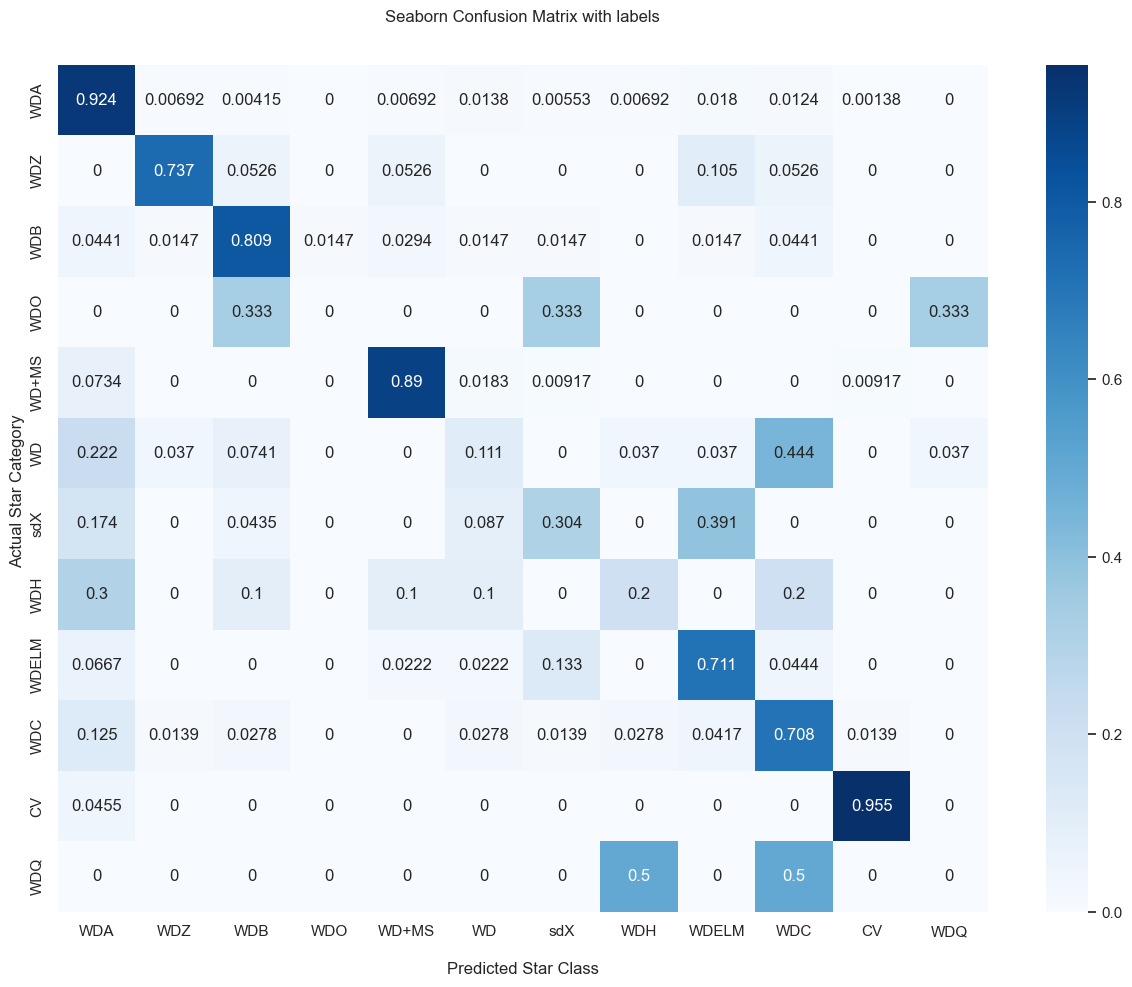

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

star_class = vsz.sort_ohe(stars_encoding)

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

The results seem pretty good for this simple example, althoug still insuficient. One of the main reasons seems to be the very little available data for minority classes. In further works, we'll incorporate other data sources to reinforce them.